# **Name :- Anirudh Pandurang Patekar**
# **Reg ID :- UST24R0101004**
# **Course :- Data Mining and WareHouse**
# **CA1 Project Topic :- COVID-19 Risk Level Classifier from Symptom Data, By Classify patients into risk categories using Rule-Based and Bayesian classifiers.**
# **Implementation :- All preprocessing, classification and evaluation logic is implemented from scratch using NumPy, Pandas and Python built-ins.**


In [ ]:
# Step 1 :- Importing Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub, os
import math
import random
import urllib.parse
import urllib.request
import json

# **Dataset Source: Centers for Disease Control and Prevention (CDC), COVID-19 Case Surveillance Public Use Data.**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/COVID_Risk_Classifier"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: /content/drive/MyDrive/COVID_Risk_Classifier
Data directory: /content/drive/MyDrive/COVID_Risk_Classifier/data
Results directory: /content/drive/MyDrive/COVID_Risk_Classifier/results


In [ ]:
CDC_API = "https://data.cdc.gov/resource/vbim-akqf.json"

print(CDC_API)

https://data.cdc.gov/resource/vbim-akqf.json


In [ ]:
def cdc_query(params):
    query_string = urllib.parse.urlencode(params)
    url = CDC_API + "?" + query_string

    with urllib.request.urlopen(url) as response:
        data = response.read().decode("utf-8")

    records = json.loads(data)

    return pd.DataFrame(records)

In [ ]:
test_df = cdc_query({
    "$limit": 5
})

print("Rows received:", len(test_df))
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df)

Rows received: 5

Columns:
['cdc_case_earliest_dt', 'cdc_report_dt', 'pos_spec_dt', 'onset_dt', 'current_status', 'sex', 'age_group', 'race_ethnicity_combined', 'hosp_yn', 'icu_yn', 'death_yn', 'medcond_yn']


,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn
0,2022-01-07T00:00:00.000,2022-01-10T00:00:00.000,2022-01-07T00:00:00.000,2022-01-07T00:00:00.000,Laboratory-confirmed case,Male,10 - 19 Years,"White, Non-Hispanic",Unknown,Unknown,Unknown,Unknown
1,2020-12-11T00:00:00.000,2021-12-06T00:00:00.000,2020-12-11T00:00:00.000,2020-12-11T00:00:00.000,Laboratory-confirmed case,Male,10 - 19 Years,"White, Non-Hispanic",Unknown,Unknown,Unknown,Unknown
2,2022-01-14T00:00:00.000,2022-01-18T00:00:00.000,2022-01-14T00:00:00.000,2022-01-14T00:00:00.000,Laboratory-confirmed case,Male,10 - 19 Years,"White, Non-Hispanic",Unknown,Unknown,Unknown,Unknown
3,2021-01-13T00:00:00.000,2021-01-13T00:00:00.000,NaN,2021-01-13T00:00:00.000,Laboratory-confirmed case,Male,10 - 19 Years,"White, Non-Hispanic",No,Missing,Missing,Missing
4,2022-01-20T00:00:00.000,2022-01-21T00:00:00.000,2022-01-20T00:00:00.000,2022-01-20T00:00:00.000,Laboratory-confirmed case,Male,10 - 19 Years,"White, Non-Hispanic",Unknown,Unknown,Unknown,Unknown


In [ ]:
count_df = cdc_query({
    "$select": "count(*) as total_records"
})

total_records = int(count_df.iloc[0]["total_records"])

print(f"Total records in CDC dataset: {total_records:,}")

Total records in CDC dataset: 106,219,500


# **Exploring and Understanding the CDC COVID-19 Dataset before Building the Model**

In [ ]:
age_distribution = cdc_query({
    "$select": "age_group, count(*) as count",
    "$group": "age_group",
    "$order": "age_group"
})

age_distribution["count"] = pd.to_numeric(
    age_distribution["count"]
)

age_distribution["percentage"] = (
    age_distribution["count"] / total_records * 100
)

display(age_distribution)

,age_group,count,percentage
0,0 - 9 Years,8466822,7.971062
1,10 - 19 Years,12428392,11.700669
2,20 - 29 Years,17658006,16.624072
3,30 - 39 Years,17078442,16.078443
4,40 - 49 Years,14620204,13.764143
5,50 - 59 Years,13716593,12.913442
6,60 - 69 Years,10471990,9.858821
7,70 - 79 Years,6392854,6.018531
8,80+ Years,4252648,4.003642
9,Missing,1133498,1.067128


In [ ]:
sex_distribution = cdc_query({
    "$select": "sex, count(*) as count",
    "$group": "sex",
    "$order": "sex"
})

sex_distribution["count"] = pd.to_numeric(
    sex_distribution["count"]
)

sex_distribution["percentage"] = (
    sex_distribution["count"] / total_records * 100
)

display(sex_distribution)

,sex,count,percentage
0,Female,56824811,53.497532
1,Male,47860885,45.058473
2,Missing,495633,0.466612
3,NA,12,0.000011
4,Other,5009,0.004716
5,Unknown,1033150,0.972656


In [ ]:
strata_distribution = cdc_query({
    "$select": "age_group, sex, count(*) as count",
    "$group": "age_group, sex",
    "$order": "age_group, sex"
})

strata_distribution["count"] = pd.to_numeric(
    strata_distribution["count"]
)

strata_distribution["percentage"] = (
    strata_distribution["count"] / total_records * 100
)

display(strata_distribution)

,age_group,sex,count,percentage
0,0 - 9 Years,Female,4020301,3.784899
1,0 - 9 Years,Male,4296926,4.045327
2,0 - 9 Years,Missing,47804,0.045005
3,0 - 9 Years,Other,456,0.000429
4,0 - 9 Years,Unknown,101335,0.095402
5,10 - 19 Years,Female,6352550,5.980587
6,10 - 19 Years,Male,5854174,5.511393
7,10 - 19 Years,Missing,63301,0.059595
8,10 - 19 Years,Other,771,0.000726
9,10 - 19 Years,Unknown,157596,0.148368


In [ ]:
TARGET_SAMPLE_SIZE = 100_000

print(f"Target sample size: {TARGET_SAMPLE_SIZE:,}")

Target sample size: 100,000


In [ ]:
strata_distribution["raw_quota"] = (
    strata_distribution["count"] / total_records
) * TARGET_SAMPLE_SIZE

strata_distribution["sample_quota"] = (
    strata_distribution["raw_quota"]
    .round()
    .astype(int)
)

print(
    "Total calculated quota:",
    strata_distribution["sample_quota"].sum()
)

display(strata_distribution)

Total calculated quota: 99999


,age_group,sex,count,percentage,raw_quota,sample_quota
0,0 - 9 Years,Female,4020301,3.784899,3784.899195,3785
1,0 - 9 Years,Male,4296926,4.045327,4045.326894,4045
2,0 - 9 Years,Missing,47804,0.045005,45.004919,45
3,0 - 9 Years,Other,456,0.000429,0.429300,0
4,0 - 9 Years,Unknown,101335,0.095402,95.401503,95
5,10 - 19 Years,Female,6352550,5.980587,5980.587369,5981
6,10 - 19 Years,Male,5854174,5.511393,5511.392917,5511
7,10 - 19 Years,Missing,63301,0.059595,59.594519,60
8,10 - 19 Years,Other,771,0.000726,0.725855,1
9,10 - 19 Years,Unknown,157596,0.148368,148.368237,148


In [ ]:
difference = TARGET_SAMPLE_SIZE - strata_distribution["sample_quota"].sum()

print("Difference before adjustment:", difference)

Difference before adjustment: 1


In [ ]:
if difference != 0:

    fractional_parts = (
        strata_distribution["raw_quota"]
        - strata_distribution["raw_quota"].astype(int)
    )

    if difference > 0:
        indices = fractional_parts.sort_values(
            ascending=False
        ).index[:difference]

        strata_distribution.loc[
            indices, "sample_quota"
        ] += 1

    else:
        indices = fractional_parts.sort_values(
            ascending=True
        ).index[:abs(difference)]

        strata_distribution.loc[
            indices, "sample_quota"
        ] -= 1

In [ ]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [ ]:
sampling_manifest = {
    "dataset": "CDC COVID-19 Case Surveillance Public Use Data",
    "dataset_id": "vbim-akqf",
    "target_sample_size": TARGET_SAMPLE_SIZE,
    "sampling_method": "Proportional Stratified Sampling",
    "stratification_variables": ["age_group", "sex"],
    "random_seed": RANDOM_SEED
}

manifest_path = os.path.join(
    DATA_DIR,
    "sampling_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(
        sampling_manifest,
        f,
        indent=4
    )

print("Sampling manifest saved:")
print(manifest_path)

Sampling manifest saved:
/content/drive/MyDrive/COVID_Risk_Classifier/data/sampling_manifest.json


In [ ]:
date_range_df = cdc_query({
    "$select": "min(cdc_case_earliest_dt) as earliest_date, "
               "max(cdc_case_earliest_dt) as latest_date"
})

print("Earliest case date:")
print(date_range_df.iloc[0]["earliest_date"])

print("\nLatest case date:")
print(date_range_df.iloc[0]["latest_date"])

Earliest case date:
2020-01-01T00:00:00.000

Latest case date:
2024-06-13T00:00:00.000


In [ ]:
year_distribution = cdc_query({
    "$select": "date_extract_y(cdc_case_earliest_dt) as case_year, count(*) as count",
    "$where": "cdc_case_earliest_dt is not null",
    "$group": "date_extract_y(cdc_case_earliest_dt)",
    "$order": "case_year"
})

year_distribution["count"] = pd.to_numeric(
    year_distribution["count"]
)

year_distribution["percentage"] = (
    year_distribution["count"] / total_records * 100
)

display(year_distribution)

,case_year,count,percentage
0,2020,20195712,19.013187
1,2021,34489725,32.470239
2,2022,41085361,38.679678
3,2023,8413979,7.921313
4,2024,2034723,1.915583


In [ ]:
print(
    "Final quota:",
    strata_distribution["sample_quota"].sum()
)

assert (
    strata_distribution["sample_quota"].sum()
    == TARGET_SAMPLE_SIZE
)

Final quota: 100000


In [ ]:
strata_distribution = cdc_query({
    "$select": """
        date_extract_y(cdc_case_earliest_dt) as case_year,
        age_group,
        sex,
        count(*) as count
    """,
    "$where": "cdc_case_earliest_dt is not null",
    "$group": "date_extract_y(cdc_case_earliest_dt), age_group, sex"
})

strata_distribution["count"] = pd.to_numeric(
    strata_distribution["count"]
)

strata_distribution["case_year"] = pd.to_numeric(
    strata_distribution["case_year"]
)

strata_distribution["percentage"] = (
    strata_distribution["count"]
    / total_records
    * 100
)

display(strata_distribution)

,case_year,age_group,sex,count,percentage
0,2020,0 - 9 Years,Female,393620,3.705723e-01
1,2020,0 - 9 Years,Male,412761,3.885925e-01
2,2020,0 - 9 Years,Missing,3237,3.047463e-03
3,2020,0 - 9 Years,Other,3,2.824340e-06
4,2020,0 - 9 Years,Unknown,6398,6.023376e-03
...,...,...,...,...,...
257,2023,NA,Missing,1,9.414467e-07
258,2023,NA,Other,4,3.765787e-06
259,2024,NA,Missing,2,1.882893e-06
260,2024,NA,NA,1,9.414467e-07


In [ ]:
strata_distribution["raw_quota"] = (
    strata_distribution["count"]
    / total_records
    * TARGET_SAMPLE_SIZE
)

strata_distribution["sample_quota"] = (
    strata_distribution["raw_quota"]
    .astype(int)
)

In [ ]:
remaining = (
    TARGET_SAMPLE_SIZE
    - strata_distribution["sample_quota"].sum()
)

print("Records remaining to allocate:", remaining)

Records remaining to allocate: 98


In [ ]:
fractional_parts = (
    strata_distribution["raw_quota"]
    - strata_distribution["sample_quota"]
)

if remaining > 0:

    largest_remainder_indices = (
        fractional_parts
        .sort_values(ascending=False)
        .index[:remaining]
    )

    strata_distribution.loc[
        largest_remainder_indices,
        "sample_quota"
    ] += 1

print(
    "Final quota:",
    strata_distribution["sample_quota"].sum()
)

Final quota: 100000


In [ ]:
invalid_quotas = strata_distribution[
    strata_distribution["sample_quota"]
    > strata_distribution["count"]
]

print(
    "Number of invalid strata:",
    len(invalid_quotas)
)

if len(invalid_quotas) > 0:
    display(invalid_quotas)
else:
    print("✓ Every sampling quota is available in the CDC population.")

Number of invalid strata: 0
✓ Every sampling quota is available in the CDC population.


In [ ]:
sampling_plan = strata_distribution[
    [
        "case_year",
        "age_group",
        "sex",
        "count",
        "percentage",
        "sample_quota"
    ]
].copy()

sampling_plan = sampling_plan.sort_values(
    ["case_year", "age_group", "sex"]
)

display(sampling_plan)

,case_year,age_group,sex,count,percentage,sample_quota
0,2020,0 - 9 Years,Female,393620,3.705723e-01,371
1,2020,0 - 9 Years,Male,412761,3.885925e-01,389
2,2020,0 - 9 Years,Missing,3237,3.047463e-03,3
3,2020,0 - 9 Years,Other,3,2.824340e-06,0
4,2020,0 - 9 Years,Unknown,6398,6.023376e-03,6
...,...,...,...,...,...,...
248,2024,Missing,Other,3,2.824340e-06,0
249,2024,Missing,Unknown,378,3.558669e-04,0
259,2024,NA,Missing,2,1.882893e-06,0
260,2024,NA,NA,1,9.414467e-07,0


In [ ]:
RNG = np.random.default_rng(42)

print("Random generator initialized.")
print("Seed = 42")

Random generator initialized.
Seed = 42


In [ ]:
SAMPLE_SIZE_LABEL = f"{TARGET_SAMPLE_SIZE // 1000}k"

SAMPLE_PATH = os.path.join(
    DATA_DIR,
    f"cdc_stratified_sample_{SAMPLE_SIZE_LABEL}.csv"
)

print("Sample will be saved to:")
print(SAMPLE_PATH)

Sample will be saved to:
/content/drive/MyDrive/COVID_Risk_Classifier/data/cdc_stratified_sample_100k.csv


In [ ]:
def get_stratum_records(
    case_year,
    age_group,
    sex,
    limit=5000,
    offset=0
):

    conditions = [
        f"date_extract_y(cdc_case_earliest_dt) = {int(case_year)}",
        f"age_group = '{age_group}'",
        f"sex = '{sex}'"
    ]

    where_clause = " AND ".join(conditions)

    params = {
        "$limit": limit,
        "$offset": offset,
        "$where": where_clause
    }

    return cdc_query(params)

In [ ]:
def escape_soql_string(value):
    return str(value).replace("'", "''")


def get_stratum_records(
    case_year,
    age_group,
    sex,
    limit=5000,
    offset=0
):

    age_value = escape_soql_string(age_group)
    sex_value = escape_soql_string(sex)

    where_clause = (
        f"date_extract_y(cdc_case_earliest_dt) = {int(case_year)} "
        f"AND age_group = '{age_value}' "
        f"AND sex = '{sex_value}'"
    )

    params = {
        "$limit": limit,
        "$offset": offset,
        "$where": where_clause
    }

    return cdc_query(params)

In [ ]:
test_stratum = get_stratum_records(
    case_year=2022,
    age_group="20 - 29 Years",
    sex="Female",
    limit=10
)

print("Records retrieved:", len(test_stratum))

display(test_stratum)

Records retrieved: 10


,cdc_case_earliest_dt,cdc_report_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn,pos_spec_dt,onset_dt
0,2022-02-11T00:00:00.000,2022-02-11T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,NaN,NaN
1,2022-03-21T00:00:00.000,2022-03-21T00:00:00.000,Probable Case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,No,Missing,NaN,NaN
2,2022-03-17T00:00:00.000,2022-03-17T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,NaN,NaN
3,2022-07-30T00:00:00.000,2022-08-09T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,2022-08-09T00:00:00.000,2022-07-30T00:00:00.000
4,2022-04-24T00:00:00.000,2022-05-05T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,2022-05-03T00:00:00.000,2022-04-24T00:00:00.000
5,2022-05-28T00:00:00.000,2022-06-02T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,2022-05-28T00:00:00.000,NaN
6,2022-08-05T00:00:00.000,2022-08-17T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,2022-08-05T00:00:00.000,NaN
7,2022-02-04T00:00:00.000,2022-02-04T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",No,Missing,No,Missing,NaN,NaN
8,2022-02-21T00:00:00.000,2022-02-21T00:00:00.000,Probable Case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,No,Missing,NaN,NaN
9,2022-03-28T00:00:00.000,2022-03-28T00:00:00.000,Laboratory-confirmed case,Female,20 - 29 Years,"Asian, Non-Hispanic",Missing,Missing,No,Missing,NaN,NaN


In [ ]:
import time

all_samples = []

print(f"Starting data collection for {TARGET_SAMPLE_SIZE} records...")

# Loop through each row in the sampling plan
for index, row in sampling_plan.iterrows():
    quota = int(row['sample_quota'])
    if quota <= 0: continue

    # Fetch the required number of records for this specific group
    stratum_df = get_stratum_records(
        case_year=row['case_year'],
        age_group=row['age_group'],
        sex=row['sex'],
        limit=quota
    )

    all_samples.append(stratum_df)
    print(f"Collected {len(stratum_df)} records for {row['case_year']} | {row['age_group']} | {row['sex']}")

# Combine all groups into one single DataFrame
final_df = pd.concat(all_samples, ignore_index=True)

# Save the final dataset to Google Drive
final_df.to_csv(SAMPLE_PATH, index=False)

print("\nSuccess! Final dataset saved to:")
print(SAMPLE_PATH)
display(final_df.head())

Starting data collection for 100000 records...
Collected 371 records for 2020 | 0 - 9 Years | Female
Collected 389 records for 2020 | 0 - 9 Years | Male
Collected 3 records for 2020 | 0 - 9 Years | Missing
Collected 6 records for 2020 | 0 - 9 Years | Unknown
Collected 1007 records for 2020 | 10 - 19 Years | Female
Collected 935 records for 2020 | 10 - 19 Years | Male
Collected 7 records for 2020 | 10 - 19 Years | Missing
Collected 16 records for 2020 | 10 - 19 Years | Unknown
Collected 1890 records for 2020 | 20 - 29 Years | Female
Collected 1662 records for 2020 | 20 - 29 Years | Male
Collected 11 records for 2020 | 20 - 29 Years | Missing
Collected 30 records for 2020 | 20 - 29 Years | Unknown
Collected 1612 records for 2020 | 30 - 39 Years | Female
Collected 1480 records for 2020 | 30 - 39 Years | Male
Collected 10 records for 2020 | 30 - 39 Years | Missing
Collected 25 records for 2020 | 30 - 39 Years | Unknown
Collected 1491 records for 2020 | 40 - 49 Years | Female
Collected 1340

,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn,onset_dt
0,2020-11-13T00:00:00.000,2022-01-21T00:00:00.000,2020-11-13T00:00:00.000,Laboratory-confirmed case,Female,0 - 9 Years,"Asian, Non-Hispanic",Unknown,Unknown,Missing,No,NaN
1,2020-08-06T00:00:00.000,2020-08-24T00:00:00.000,NaN,Laboratory-confirmed case,Female,0 - 9 Years,"Asian, Non-Hispanic",No,Missing,No,Missing,2020-08-06T00:00:00.000
2,2020-12-15T00:00:00.000,2021-02-19T00:00:00.000,NaN,Laboratory-confirmed case,Female,0 - 9 Years,"Asian, Non-Hispanic",Missing,Missing,Missing,Missing,NaN
3,2020-12-15T00:00:00.000,2020-12-19T00:00:00.000,NaN,Probable Case,Female,0 - 9 Years,"Asian, Non-Hispanic",No,Missing,Missing,Missing,2020-12-15T00:00:00.000
4,2020-11-20T00:00:00.000,2021-04-20T00:00:00.000,2020-11-20T00:00:00.000,Laboratory-confirmed case,Female,0 - 9 Years,"Asian, Non-Hispanic",Missing,Missing,No,Missing,NaN


# **Model Development and Implementation**

In [ ]:
# ============================================================
# DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================

# Load the sampled CDC dataset
df = pd.read_csv(SAMPLE_PATH)

In [ ]:
df.info()
print("=====================================================")
print("Total Values Present: ")
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   cdc_case_earliest_dt     100000 non-null  object
 1   cdc_report_dt            92188 non-null   object
 2   pos_spec_dt              43218 non-null   object
 3   current_status           100000 non-null  object
 4   sex                      100000 non-null  object
 5   age_group                100000 non-null  object
 6   race_ethnicity_combined  100000 non-null  object
 7   hosp_yn                  100000 non-null  object
 8   icu_yn                   100000 non-null  object
 9   death_yn                 100000 non-null  object
 10  medcond_yn               100000 non-null  object
 11  onset_dt                 38833 non-null   object
dtypes: object(12)
memory usage: 9.2+ MB
Total Values Present: 


(100000, 12)

In [ ]:
print("Missing values before cleaning:\n")

print(
    df[SELECTED_COLUMNS]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values before cleaning:

medcond_yn                 90202
race_ethnicity_combined     4032
sex                         1441
age_group                   1068
risk_level                     0
dtype: int64


In [ ]:
print("\nMissing percentage:\n")

print(
    (df[SELECTED_COLUMNS].isna().mean() * 100)
    .sort_values(ascending=False)
)


Missing percentage:

medcond_yn                 90.202
race_ethnicity_combined     4.032
sex                         1.441
age_group                   1.068
risk_level                  0.000
dtype: float64


In [ ]:
# ============================================================
# 1. CREATE TARGET VARIABLE
# ============================================================

def calculate_risk(row):

    # High Risk: Death or ICU
    if row['death_yn'] == 'Yes' or row['icu_yn'] == 'Yes':
        return 2

    # Medium Risk: Hospitalized
    elif row['hosp_yn'] == 'Yes':
        return 1

    # Low Risk: Explicitly not hospitalized
    elif row['hosp_yn'] == 'No':
        return 0

    # Risk cannot be determined
    else:
        return np.nan


df['risk_level'] = df.apply(
    calculate_risk,
    axis=1
)


# ============================================================
# 2. SELECT FEATURES
# ============================================================

FEATURES = [
    'age_group',
    'sex',
    'medcond_yn',
    'race_ethnicity_combined'
]

TARGET = 'risk_level'

SELECTED_COLUMNS = FEATURES + [TARGET]


# ============================================================
# 3. HANDLE MISSING FEATURE VALUES
# ============================================================

# Keep missing information instead of deleting records
df[FEATURES] = df[FEATURES].fillna('Missing')

df[FEATURES] = df[FEATURES].replace(
    ['Unknown', 'NA'],
    'Missing'
)


# ============================================================
# 4. REMOVE ONLY RECORDS WITH UNKNOWN TARGET
# ============================================================

df_clean = (
    df[SELECTED_COLUMNS]
    .dropna(subset=[TARGET])
    .copy()
)


# ============================================================
# 5. DATASET SUMMARY
# ============================================================

print("=" * 50)
print("DATA PREPROCESSING COMPLETED")
print("=" * 50)

print(f"Original records: {len(df):,}")
print(f"Cleaned records : {len(df_clean):,}")

print("\nRisk Level Distribution:")

print(
    df_clean['risk_level']
    .value_counts()
    .sort_index()
)


# ============================================================
# 6. SAVE CLEANED DATASET
# ============================================================

CLEANED_DATA_PATH = os.path.join(
    DATA_DIR,
    "cdc_cleaned_data.csv"
)

df_clean.to_csv(
    CLEANED_DATA_PATH,
    index=False
)

print("\nCleaned dataset saved successfully.")

DATA PREPROCESSING COMPLETED
Original records: 100,000
Cleaned records : 35,940

Risk Level Distribution:
risk_level
0.0    31448
1.0     3109
2.0     1383
Name: count, dtype: int64

Cleaned dataset saved successfully.


In [ ]:
print("Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nFeature Distributions:")

for column in FEATURES:
    print(f"\n{column}:")
    print(df_clean[column].value_counts())

Dataset Shape: (35940, 5)

Missing Values:
age_group                  0
sex                        0
medcond_yn                 0
race_ethnicity_combined    0
risk_level                 0
dtype: int64

Feature Distributions:

age_group:
age_group
30 - 39 Years    6573
40 - 49 Years    5484
50 - 59 Years    5000
20 - 29 Years    4663
10 - 19 Years    4259
60 - 69 Years    3831
0 - 9 Years      2297
70 - 79 Years    1937
80+ Years        1702
Missing           194
Name: count, dtype: int64

sex:
sex
Female     20077
Male       15552
Missing      310
Other          1
Name: count, dtype: int64

medcond_yn:
medcond_yn
Missing    30524
No          2912
Yes         2504
Name: count, dtype: int64

race_ethnicity_combined:
race_ethnicity_combined
White, Non-Hispanic                                     8976
American Indian/Alaska Native, Non-Hispanic             8468
Native Hawaiian/Other Pacific Islander, Non-Hispanic    6419
Asian, Non-Hispanic                                     5776
Black, N

In [ ]:
# ============================================================
# RULE-BASED CLASSIFIER
# ============================================================


# ============================================================
# 1. TRAIN-TEST SPLIT (80% / 20%)
# ============================================================

# Shuffle the dataset using a fixed random seed
np.random.seed(RANDOM_SEED)

shuffled_indices = np.random.permutation(len(df_clean))

df_shuffled = (
    df_clean
    .iloc[shuffled_indices]
    .reset_index(drop=True)
)

# Calculate split position
split_index = int(len(df_shuffled) * 0.80)

# Create training and testing datasets
train_df = df_shuffled.iloc[:split_index].copy()
test_df = df_shuffled.iloc[split_index:].copy()

print(f"Training samples: {len(train_df):,}")
print(f"Testing samples : {len(test_df):,}")


# ============================================================
# 2. RULE-BASED CLASSIFIER
# ============================================================

def rule_based_predict(row):
    """
    Predict COVID-19 risk level using predefined rules.

    High Risk (2):
        Age 70+ and medical condition = Yes

    Medium Risk (1):
        Age 50-69 and medical condition = Yes

    Low Risk (0):
        All other cases
    """

    high_risk_ages = [
        '70 - 79 Years',
        '80+ Years'
    ]

    medium_risk_ages = [
        '50 - 59 Years',
        '60 - 69 Years'
    ]

    # High Risk
    if (
        row['age_group'] in high_risk_ages
        and row['medcond_yn'] == 'Yes'
    ):
        return 2

    # Medium Risk
    elif (
        row['age_group'] in medium_risk_ages
        and row['medcond_yn'] == 'Yes'
    ):
        return 1

    # Low Risk
    return 0


# ============================================================
# 3. MAKE PREDICTIONS
# ============================================================

test_df['rb_prediction'] = test_df.apply(
    rule_based_predict,
    axis=1
)


# ============================================================
# 4. EVALUATE MODEL ACCURACY
# ============================================================

correct_predictions = (
    test_df['rb_prediction']
    == test_df['risk_level']
).sum()

accuracy = (
    correct_predictions
    / len(test_df)
) * 100


# ============================================================
# 5. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 50)
print("RULE-BASED CLASSIFIER RESULTS")
print("=" * 50)

print(f"Total Test Samples : {len(test_df):,}")
print(f"Correct Predictions: {correct_predictions:,}")
print(f"Accuracy           : {accuracy:.2f}%")


# ============================================================
# 6. SAMPLE PREDICTIONS
# ============================================================

display(
    test_df[
        [
            'age_group',
            'medcond_yn',
            'risk_level',
            'rb_prediction'
        ]
    ].head(10)
)

Training samples: 28,752
Testing samples : 7,188

RULE-BASED CLASSIFIER RESULTS
Total Test Samples : 7,188
Correct Predictions: 6,211
Accuracy           : 86.41%


,age_group,medcond_yn,risk_level,rb_prediction
28752,0 - 9 Years,Missing,0.0,0
28753,30 - 39 Years,Missing,0.0,0
28754,30 - 39 Years,Yes,0.0,0
28755,50 - 59 Years,Missing,0.0,0
28756,60 - 69 Years,Missing,0.0,0
28757,30 - 39 Years,Yes,0.0,0
28758,10 - 19 Years,No,0.0,0
28759,10 - 19 Years,Missing,0.0,0
28760,40 - 49 Years,Missing,0.0,0
28761,20 - 29 Years,Missing,0.0,0


In [ ]:
# ============================================================
# BAYESIAN CLASSIFIER IMPLEMENTATION FROM SCRATCH
# ============================================================

import math


# ============================================================
# 1. DEFINE FEATURES AND CLASSES
# ============================================================

FEATURES = [
    'age_group',
    'sex',
    'medcond_yn',
    'race_ethnicity_combined'
]

RISK_LEVELS = [0, 1, 2]


# ============================================================
# 2. CALCULATE PRIOR PROBABILITIES
#    P(Risk_Level)
# ============================================================

priors = (
    train_df['risk_level']
    .value_counts(normalize=True)
    .to_dict()
)


# ============================================================
# 3. CALCULATE LIKELIHOOD PROBABILITIES
#    P(Feature | Risk_Level)
# ============================================================

likelihoods = {}

for feature in FEATURES:

    likelihoods[feature] = {}

    for risk in RISK_LEVELS:

        # Select records belonging to the current risk level
        subset = train_df[
            train_df['risk_level'] == risk
        ]

        # Calculate probability of each feature value
        probabilities = (
            subset[feature]
            .value_counts(normalize=True)
            .to_dict()
        )

        likelihoods[feature][risk] = probabilities


# ============================================================
# 4. BAYESIAN PREDICTION FUNCTION
# ============================================================

def bayesian_predict(row):
    """
    Predict the COVID-19 risk level using Bayes' Theorem.

    Posterior Score:
    P(Risk) × P(Age | Risk) × P(Sex | Risk)
            × P(Medical Condition | Risk)
    """

    posterior_scores = {}

    for risk in RISK_LEVELS:

        # Get prior probability
        prior = priors.get(risk, 0)

        # Use log probabilities for numerical stability
        if prior > 0:
            score = math.log(prior)
        else:
            score = -1e9

        # Add log likelihood for each feature
        for feature in FEATURES:

            value = row[feature]

            # Use a small probability for unseen values
            probability = likelihoods[
                feature
            ][risk].get(value, 1e-6)

            score += math.log(probability)

        posterior_scores[risk] = score


    # Return class with highest posterior probability
    return max(
        posterior_scores,
        key=posterior_scores.get
    )


# ============================================================
# 5. MAKE PREDICTIONS
# ============================================================

test_df['bayesian_prediction'] = test_df.apply(
    bayesian_predict,
    axis=1
)


# ============================================================
# 6. EVALUATE BAYESIAN CLASSIFIER
# ============================================================

bayesian_correct = (
    test_df['bayesian_prediction']
    == test_df['risk_level']
).sum()

bayesian_accuracy = (
    bayesian_correct
    / len(test_df)
) * 100


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("=" * 50)
print("BAYESIAN CLASSIFIER RESULTS")
print("=" * 50)

print(f"Total Test Samples : {len(test_df):,}")
print(f"Correct Predictions: {bayesian_correct:,}")
print(f"Accuracy           : {bayesian_accuracy:.2f}%")

BAYESIAN CLASSIFIER RESULTS
Total Test Samples : 7,188
Correct Predictions: 6,274
Accuracy           : 87.28%


Visualization saved successfully:
/content/drive/MyDrive/COVID_Risk_Classifier/results/final_model_visualization.png


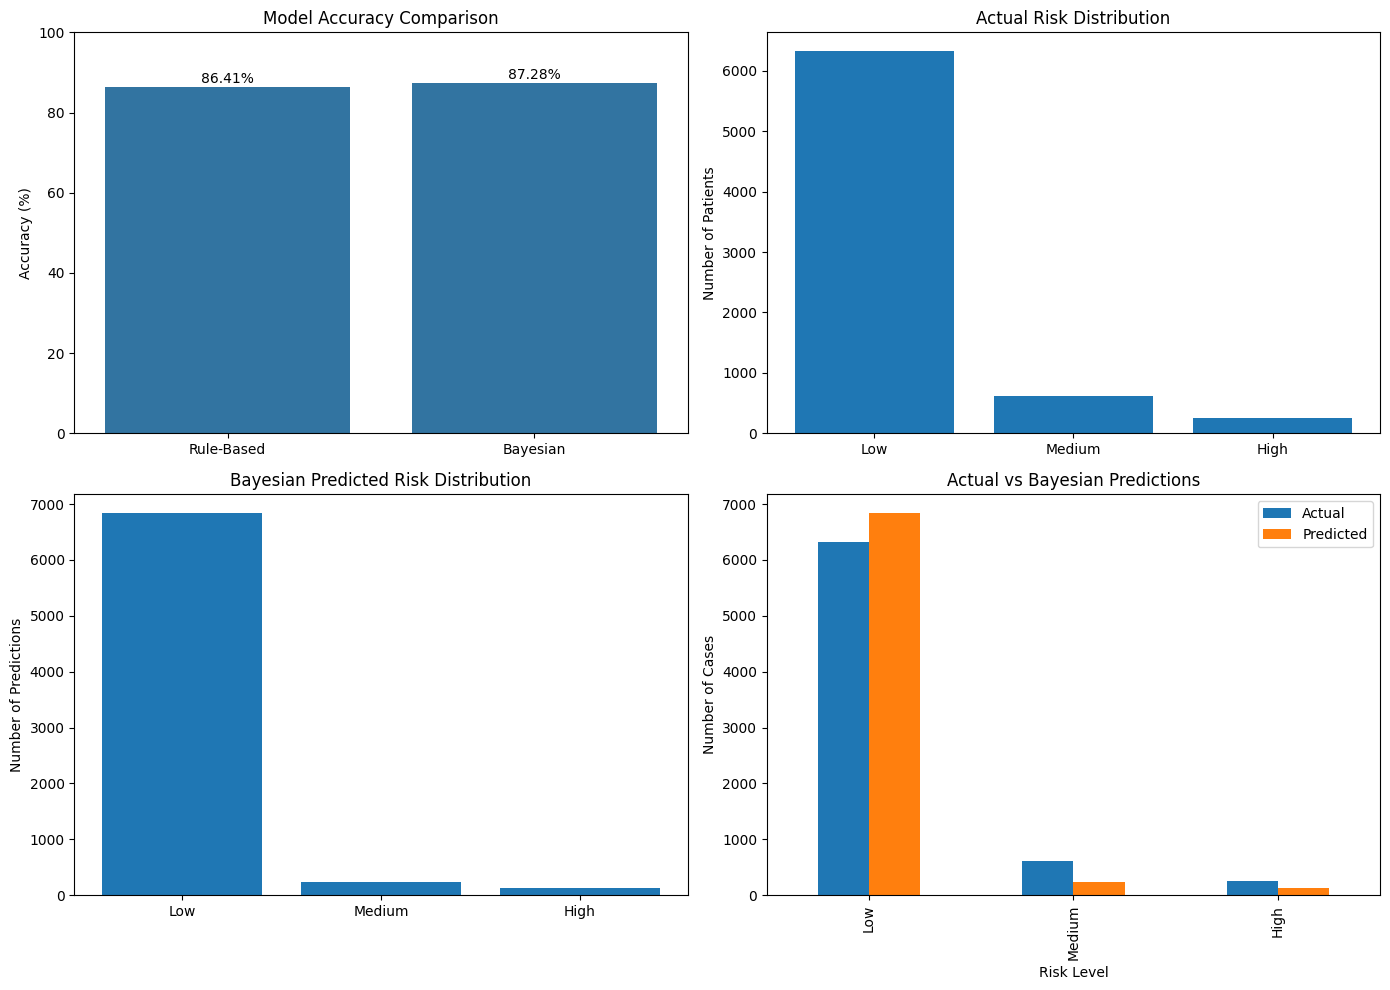

In [ ]:
# ============================================================
# STEP 5: FINAL VISUALIZATION AND REPORTING
# ============================================================

# Create a figure with 4 visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# ============================================================
# 1. MODEL ACCURACY COMPARISON
# ============================================================

models = ['Rule-Based', 'Bayesian']

accuracies = [
    accuracy,
    bayesian_accuracy
]

sns.barplot(
    x=models,
    y=accuracies,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(0, 100)

# Add accuracy values
for i, value in enumerate(accuracies):
    axes[0, 0].text(
        i,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )


# ============================================================
# 2. ACTUAL RISK DISTRIBUTION
# ============================================================

actual_counts = (
    test_df['risk_level']
    .value_counts()
    .sort_index()
)

risk_labels = ['Low', 'Medium', 'High']

axes[0, 1].bar(
    risk_labels,
    actual_counts.values
)

axes[0, 1].set_title('Actual Risk Distribution')
axes[0, 1].set_ylabel('Number of Patients')


# ============================================================
# 3. BAYESIAN PREDICTED RISK DISTRIBUTION
# ============================================================

predicted_counts = (
    test_df['bayesian_prediction']
    .value_counts()
    .sort_index()
)

axes[1, 0].bar(
    risk_labels,
    predicted_counts.values
)

axes[1, 0].set_title('Bayesian Predicted Risk Distribution')
axes[1, 0].set_ylabel('Number of Predictions')


# ============================================================
# 4. ACTUAL VS BAYESIAN PREDICTIONS
# ============================================================

comparison_data = pd.DataFrame({
    'Actual': actual_counts.values,
    'Predicted': predicted_counts.values
}, index=risk_labels)

comparison_data.plot(
    kind='bar',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Actual vs Bayesian Predictions')
axes[1, 1].set_ylabel('Number of Cases')
axes[1, 1].set_xlabel('Risk Level')
axes[1, 1].legend()


# ============================================================
# FINALIZE AND SAVE
# ============================================================

plt.tight_layout()

plot_path = os.path.join(
    RESULTS_DIR,
    'final_model_visualization.png'
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"Visualization saved successfully:")
print(plot_path)

plt.show()

In [ ]:
# ============================================================
# STEP 6: MANUAL PATIENT RISK TESTING
# ============================================================

RISK_LABELS = {
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
}


def test_patient_risk(age, sex, has_med_cond, race_ethnicity):
    """
    Predicts the risk level of a hypothetical patient
    using both Rule-Based and Bayesian classifiers.
    """

    # Create patient data
    patient = pd.Series({
        'age_group': age,
        'sex': sex,
        'medcond_yn': has_med_cond,
        'race_ethnicity_combined': race_ethnicity
    })

    # Get predictions
    rule_based_result = rule_based_predict(patient)
    bayesian_result = bayesian_predict(patient)

    # Display results
    print("\n" + "=" * 55)
    print("PATIENT RISK PREDICTION")
    print("=" * 55)

    print(f"Age Group          : {age}")
    print(f"Sex                : {sex}")
    print(f"Medical Condition  : {has_med_cond}")
    print(f"Race/Ethnicity     : {race_ethnicity}")

    print("-" * 55)

    print(
        f"Rule-Based Model   : "
        f"{RISK_LABELS[rule_based_result]}"
    )

    print(
        f"Bayesian Model     : "
        f"{RISK_LABELS[bayesian_result]}"
    )

    print("=" * 55)

In [ ]:
# ============================================================
# TEST CASES
# ============================================================

# Test Case 1: Elderly patient with medical condition
test_patient_risk(
    age='80+ Years',
    sex='Male',
    has_med_cond='Yes',
    race_ethnicity='Missing'
)


# Test Case 2: Young patient without medical condition
test_patient_risk(
    age='20 - 29 Years',
    sex='Female',
    has_med_cond='No',
    race_ethnicity='White, Non-Hispanic'
)


# Test Case 3: Older patient with medical condition
test_patient_risk(
    age='60 - 69 Years',
    sex='Female',
    has_med_cond='Yes',
    race_ethnicity='Black, Non-Hispanic'
)


PATIENT RISK PREDICTION
Age Group          : 80+ Years
Sex                : Male
Medical Condition  : Yes
Race/Ethnicity     : Missing
-------------------------------------------------------
Rule-Based Model   : High Risk
Bayesian Model     : High Risk

PATIENT RISK PREDICTION
Age Group          : 20 - 29 Years
Sex                : Female
Medical Condition  : No
Race/Ethnicity     : White, Non-Hispanic
-------------------------------------------------------
Rule-Based Model   : Low Risk
Bayesian Model     : Low Risk

PATIENT RISK PREDICTION
Age Group          : 60 - 69 Years
Sex                : Female
Medical Condition  : Yes
Race/Ethnicity     : Black, Non-Hispanic
-------------------------------------------------------
Rule-Based Model   : Medium Risk
Bayesian Model     : Low Risk


# **Conclusion**

**This project developed a COVID-19 Risk Level Classifier using real-world CDC COVID-19 surveillance data. A 100,000-record stratified sample was collected and preprocessed, resulting in 35,940 usable records.**

# **Two approaches were implemented:**

**Rule-Based Classifier: Uses predefined rules based on age and medical conditions.
Bayesian Classifier: Uses probability patterns learned from Age, Sex, Medical Condition, and Race/Ethnicity.**

**The Bayesian classifier achieved 87.28% accuracy. However, the dataset was imbalanced, with Low Risk cases being the majority, so accuracy alone does not represent complete model performance.**

**Overall, the project demonstrates an end-to-end classification pipeline, including data sampling, preprocessing, feature selection, model implementation, evaluation, visualization, and interactive testing, using custom logic built from scratch.**